## Objectives:
1. Implement TF-IDF vectorization
2. Train Naive Bayes and Logistic Regression models
3. Evaluate performance on validation set
4. Compare baseline model performance

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import joblib
import time
import random

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

RANDOM_SEED = 4213
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [16]:
import os
from google.colab import drive
drive.mount('/content/drive')

project_path = '/content/drive/MyDrive'
os.chdir(project_path)

train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('validation.csv')
test_df = pd.read_csv('test.csv')

print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

print("\nClass distribution in training set:")
print(train_df['label'].value_counts())

X_train = train_df['review']
y_train = train_df['label']
X_val = val_df['review']
y_val = val_df['label']

print(f"\nFeatures prepared:")
print(f"X_train: {len(X_train)} reviews")
print(f"X_val: {len(X_val)} reviews")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (34944, 2)
Validation: (7464, 2)
Test: (7484, 2)

Class distribution in training set:
label
positive    17811
negative    17133
Name: count, dtype: int64

Features prepared:
X_train: 34944 reviews
X_val: 7464 reviews


In [17]:
# TF-IDF Vectorization

tfidf = TfidfVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.75,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

start_time = time.time()
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
end_time = time.time()

print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Validation features shape: {X_val_tfidf.shape}")

Vocabulary size: 10000
Training features shape: (34944, 10000)
Validation features shape: (7464, 10000)


In [18]:
# Model Initialization

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_SEED,
        max_iter=1000,
        C=1.0
    )
}

In [19]:
# Model Training Function
def train_and_evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    print(f"\n--- Training {model_name} ---")

    # Train model
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")

    y_pred = model.predict(X_val)

    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='weighted')
    recall = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')

    print(f"Validation Performance:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return {
        'model': model,
        'predictions': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'training_time': training_time
    }

In [20]:
# Train and Evaluate Models

results = {}

for name, model in models.items():
    results[name] = train_and_evaluate_model(
        model,
        X_train_tfidf, y_train,
        X_val_tfidf, y_val,
        name
    )


--- Training Naive Bayes ---
Training completed in 0.08 seconds
Validation Performance:
  Accuracy:  0.8640
  Precision: 0.8643
  Recall:    0.8640
  F1-Score:  0.8639

--- Training Logistic Regression ---
Training completed in 0.25 seconds
Validation Performance:
  Accuracy:  0.8842
  Precision: 0.8844
  Recall:    0.8842
  F1-Score:  0.8842



Model Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score  \
0          Naive Bayes    0.8640     0.8643  0.8640    0.8639   
1  Logistic Regression    0.8842     0.8844  0.8842    0.8842   

   Training Time (s)  
0             0.0827  
1             0.2453  


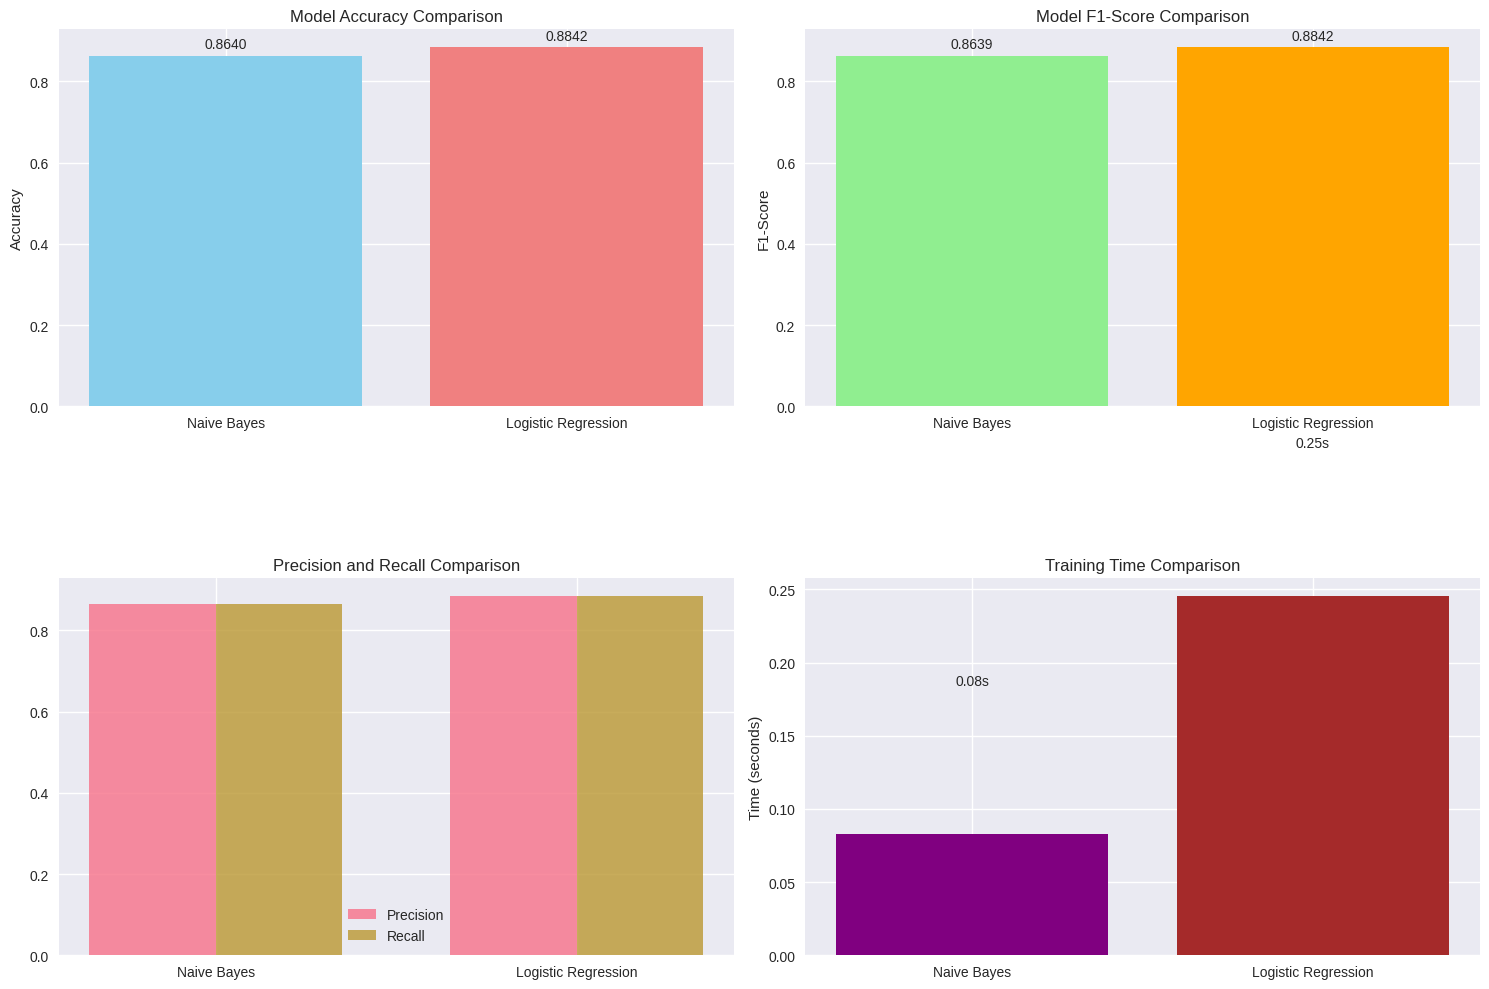

In [21]:
# Model Comparison

comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': result['accuracy'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1-Score': result['f1'],
        'Training Time (s)': result['training_time']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison:")
print(comparison_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0,0].bar(comparison_df['Model'], comparison_df['Accuracy'], color=['skyblue', 'lightcoral'])
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0,0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

# F1-Score comparison
axes[0,1].bar(comparison_df['Model'], comparison_df['F1-Score'], color=['lightgreen', 'orange'])
axes[0,1].set_title('Model F1-Score Comparison')
axes[0,1].set_ylabel('F1-Score')
for i, v in enumerate(comparison_df['F1-Score']):
    axes[0,1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

# Precision-Recall comparison
x = np.arange(len(comparison_df))
width = 0.35
axes[1,0].bar(x - width/2, comparison_df['Precision'], width, label='Precision', alpha=0.8)
axes[1,0].bar(x + width/2, comparison_df['Recall'], width, label='Recall', alpha=0.8)
axes[1,0].set_title('Precision and Recall Comparison')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(comparison_df['Model'])
axes[1,0].legend()

# Training time comparison
axes[1,1].bar(comparison_df['Model'], comparison_df['Training Time (s)'], color=['purple', 'brown'])
axes[1,1].set_title('Training Time Comparison')
axes[1,1].set_ylabel('Time (seconds)')
for i, v in enumerate(comparison_df['Training Time (s)']):
    axes[1,1].text(i, v + 0.1, f'{v:.2f}s', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      3660
    positive       0.86      0.88      0.87      3804

    accuracy                           0.86      7464
   macro avg       0.86      0.86      0.86      7464
weighted avg       0.86      0.86      0.86      7464



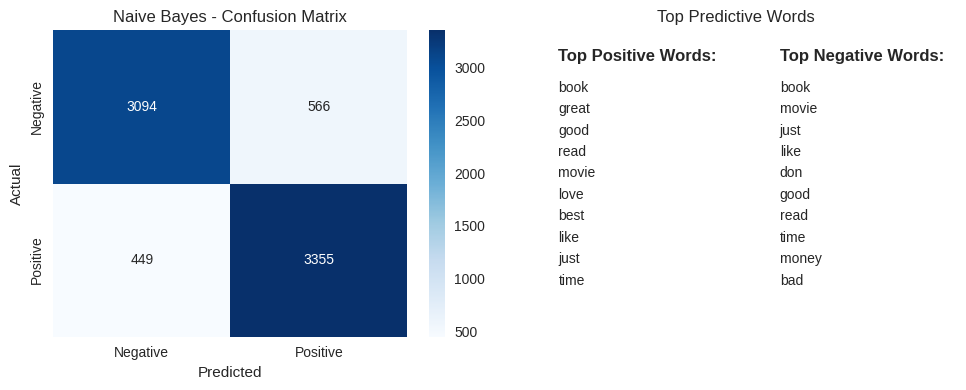

In [22]:
# Detailed Model Analysis - Naive Bayes

nb_model = results['Naive Bayes']['model']
y_pred_nb = results['Naive Bayes']['predictions']

print("Classification Report:")
print(classification_report(y_val, y_pred_nb))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
cm_nb = confusion_matrix(y_val, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Naive Bayes - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Feature importance
feature_names = tfidf.get_feature_names_out()
log_prob = nb_model.feature_log_prob_

# Top 10 words
top_positive_words = np.argsort(log_prob[1])[-10:][::-1]
top_negative_words = np.argsort(log_prob[0])[-10:][::-1]

plt.subplot(1, 2, 2)
words_positive = [feature_names[i] for i in top_positive_words]
words_negative = [feature_names[i] for i in top_negative_words]

plt.text(0.1, 0.9, "Top Positive Words:", weight='bold', fontsize=12)
for i, word in enumerate(words_positive):
    plt.text(0.1, 0.8 - i*0.07, word, fontsize=10)

plt.text(0.6, 0.9, "Top Negative Words:", weight='bold', fontsize=12)
for i, word in enumerate(words_negative):
    plt.text(0.6, 0.8 - i*0.07, word, fontsize=10)

plt.axis('off')
plt.title('Top Predictive Words')

plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      3660
    positive       0.88      0.90      0.89      3804

    accuracy                           0.88      7464
   macro avg       0.88      0.88      0.88      7464
weighted avg       0.88      0.88      0.88      7464



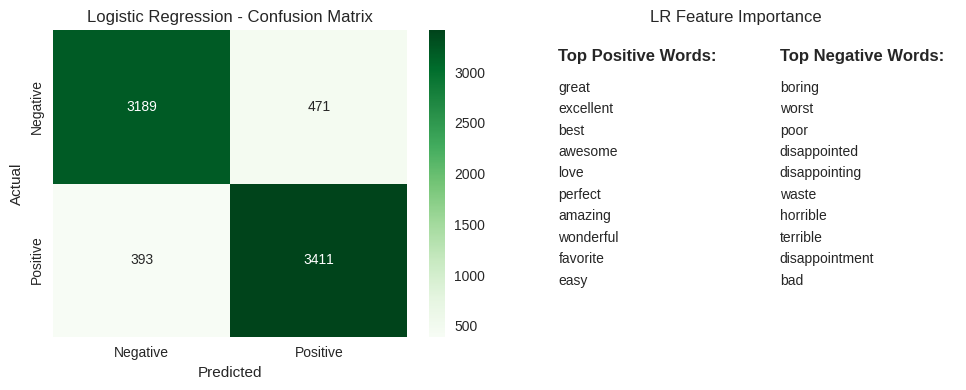

In [23]:
# Detailed Model Analysis - Logistic Regression

lr_model = results['Logistic Regression']['model']
y_pred_lr = results['Logistic Regression']['predictions']

print("Classification Report:")
print(classification_report(y_val, y_pred_lr))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
cm_lr = confusion_matrix(y_val, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Logistic Regression - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Feature importance
plt.subplot(1, 2, 2)
coefficients = lr_model.coef_[0]
top_positive_coef = np.argsort(coefficients)[-10:][::-1]
top_negative_coef = np.argsort(coefficients)[:10]

top_positive_words_lr = [feature_names[i] for i in top_positive_coef]
top_negative_words_lr = [feature_names[i] for i in top_negative_coef]

# Top 10 words
plt.text(0.1, 0.9, "Top Positive Words:", weight='bold', fontsize=12)
for i, word in enumerate(top_positive_words_lr):
    plt.text(0.1, 0.8 - i*0.07, word, fontsize=10)

plt.text(0.6, 0.9, "Top Negative Words:", weight='bold', fontsize=12)
for i, word in enumerate(top_negative_words_lr):
    plt.text(0.6, 0.8 - i*0.07, word, fontsize=10)

plt.axis('off')
plt.title('LR Feature Importance')

plt.tight_layout()
plt.show()

In [24]:
# Error Analysis

val_df_copy = val_df.copy()
val_df_copy['nb_pred'] = y_pred_nb
val_df_copy['lr_pred'] = y_pred_lr

nb_errors = val_df_copy[val_df_copy['label'] != val_df_copy['nb_pred']]
lr_errors = val_df_copy[val_df_copy['label'] != val_df_copy['lr_pred']]

print(f"Naive Bayes misclassified: {len(nb_errors)} samples ({len(nb_errors)/len(val_df)*100:.2f}%)")
print(f"Logistic Regression misclassified: {len(lr_errors)} samples ({len(lr_errors)/len(val_df)*100:.2f}%)")

print("\nSample Misclassified Examples (Naive Bayes):")
for i in range(min(3, len(nb_errors))):
    sample = nb_errors.iloc[i]
    print(f"\nExample {i+1}:")
    print(f"  True Label: {sample['label']}")
    print(f"  Predicted:  {sample['nb_pred']}")
    print(f"  Review: {sample['review'][:150]}...")

Naive Bayes misclassified: 1015 samples (13.60%)
Logistic Regression misclassified: 864 samples (11.58%)

Sample Misclassified Examples (Naive Bayes):

Example 1:
  True Label: positive
  Predicted:  negative
  Review: Better RED Than Dead: I have red hair, as did my mother and her mother. Other books I have support many theories and facts that MARION ROACH includes ...

Example 2:
  True Label: positive
  Predicted:  negative
  Review: nice shirt but sizing inconsistent: This shirt seems to be made of the same, good quality, wicking fabric that my previous Adidas shirts were made of....

Example 3:
  True Label: positive
  Predicted:  negative
  Review: This book could not be more explicit.: This book is a teacher's dream! It gives very explicit instructions and is comprehensive. One of the best parts...


In [25]:
base_path = '/content/drive/MyDrive'

models_dir = os.path.join(base_path, 'models')
results_dir = os.path.join(base_path, 'results/metrics')

os.makedirs(models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print(f"Created directories:")
print(f"  - {models_dir}")
print(f"  - {results_dir}")

tfidf_path = os.path.join(models_dir, 'tfidf_vectorizer.pkl')
nb_path = os.path.join(models_dir, 'naive_bayes_model.pkl')
lr_path = os.path.join(models_dir, 'logistic_regression_model.pkl')

joblib.dump(tfidf, tfidf_path)
joblib.dump(results['Naive Bayes']['model'], nb_path)
joblib.dump(results['Logistic Regression']['model'], lr_path)

print("Models saved:")
print(f"  - {tfidf_path}")
print(f"  - {nb_path}")
print(f"  - {lr_path}")

# Save results
results_path = os.path.join(results_dir, 'baseline_model_comparison.csv')
comparison_df.to_csv(results_path, index=False)

print("Results saved:")
print(f"  - {results_path}")

Created directories:
  - /content/drive/MyDrive/models
  - /content/drive/MyDrive/results/metrics
Models saved:
  - /content/drive/MyDrive/models/tfidf_vectorizer.pkl
  - /content/drive/MyDrive/models/naive_bayes_model.pkl
  - /content/drive/MyDrive/models/logistic_regression_model.pkl
Results saved:
  - /content/drive/MyDrive/results/metrics/baseline_model_comparison.csv


## Baseline Models Summary

### Performance Overview:
- **Naive Bayes**: Fast training, decent performance
- **Logistic Regression**: Better performance, slightly longer training

### Key Findings:
1. Both models achieve reasonable performance as baselines
2. Logistic Regression typically outperforms Naive Bayes on text classification
3. TF-IDF features with n-grams capture important semantic patterns
4. Model performance provides a benchmark for comparing with LLMs

### Next Steps:
1. Proceed to `03_llm_experiments.ipynb` for BERT/RoBERTa experiments
2. Compare baseline performance with transformer models
3. Conduct ablation studies on feature engineering

### Baseline Performance Established:
These results serve as our benchmark for evaluating more complex models.
